# Notebook 01 — ARIMA
**Role:** Statistical baseline  
**Data:** `Final_Cleaned_1m.parquet` — 1,303 services  
**Features (X):** `total_traffic`, `avg_node_stress`, `replica_count`, `avg_response_time`  
**Target (y):** `total_cpu_demand`  
**Pipeline:** identical to LSTM — every-4th-sample val split, log1p + MinMaxScaler  
**Metrics:** R², MAE, RMSE, MAPE → `results/all_models_results.csv`


In [3]:
!pip install statsmodels


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.6 MB 16.8 MB/s eta 0:00:01
   ------------- -------------------------- 3.1/9.6 MB 16.8 MB/s eta 0:00:01
   ---------------- ----------------------- 3.9/9.6 MB 7.1 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.6 MB 8.6 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.6 MB 8.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 7.3 MB/s  0:00:01

   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ---

In [5]:
import random, os, warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_PATH    = str(PROJECT_ROOT / 'cleanData' / 'Final_Cleaned_1m.parquet')
PLOTS_DIR    = str(PROJECT_ROOT / 'plots')
RESULTS_CSV  = str(PROJECT_ROOT / 'results' / 'all_models_results.csv')
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(str(PROJECT_ROOT / 'results'), exist_ok=True)

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})

def save_result(model_name, r2, mae, rmse, mape):
    row = pd.DataFrame([{'model':model_name,'R2':round(float(r2),4),
        'MAE':round(float(mae),4),'RMSE':round(float(rmse),4),'MAPE':round(float(mape),2)}])
    if os.path.exists(RESULTS_CSV):
        ex = pd.read_csv(RESULTS_CSV)
        row = pd.concat([ex[ex['model']!=model_name], row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"  Saved \u2192 results/all_models_results.csv")

print(f"Project root : {PROJECT_ROOT}")
print(f"Data         : {DATA_PATH}")


Project root : C:\Users\phone\Documents\Alibaba\Cloud_Autoscale
Data         : C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\cleanData\Final_Cleaned_1m.parquet


## 1. Load Data

In [6]:
print("Loading Cleaned 1-Minute Data...")
df_final_1m = pl.read_parquet(DATA_PATH)
print(f"Loaded Shape: {df_final_1m.shape}")
print(f"Columns: {df_final_1m.columns}")
print(f"Timestamp range: {df_final_1m['timestamp'].min()} to {df_final_1m['timestamp'].max()}")
print(f"Unique services: {df_final_1m['msname'].n_unique()}")


Loading Cleaned 1-Minute Data...
Loaded Shape: (937986, 8)
Columns: ['msname', 'timestamp', 'total_cpu_demand', 'total_memory_demand', 'total_traffic', 'avg_node_stress', 'avg_response_time', 'replica_count']
Timestamp range: 0 to 43140000
Unique services: 1303


## 2. Build Sliding Windows

In [7]:
print("Building sliding windows...")

WINDOW_SIZE   = 5
PREDICT_STEPS = 1
FEATURES = ['total_traffic','avg_node_stress','replica_count','avg_response_time']

X_raw, y_raw = [], []
for name, group in df_final_1m.sort('timestamp').group_by('msname'):
    group   = group.with_columns(pl.col('avg_response_time').fill_null(0))
    X_array = group.select(FEATURES).to_numpy()
    y_array = group.select('total_cpu_demand').to_numpy()
    for i in range(WINDOW_SIZE, len(X_array) - PREDICT_STEPS + 1):
        X_raw.append(X_array[i-WINDOW_SIZE:i, :])
        y_raw.append(y_array[i:i+PREDICT_STEPS, 0])

X_raw = np.array(X_raw)
y_raw = np.array(y_raw).reshape(-1, PREDICT_STEPS)
print(f"X_raw Shape: {X_raw.shape}  (samples, {WINDOW_SIZE} timesteps, {len(FEATURES)} features)")
print(f"y_raw Shape: {y_raw.shape}")
print(f"y_raw max:   {y_raw.max():.4f} cores | mean: {y_raw.mean():.4f} cores")


Building sliding windows...
X_raw Shape: (931471, 5, 4)  (samples, 5 timesteps, 4 features)
y_raw Shape: (931471, 1)
y_raw max:   1712.0461 cores | mean: 13.9350 cores


## 3. Split & Scale

In [8]:
print("Splitting into Train/Validation sets...")
val_indices   = np.arange(0, len(X_raw), 4)
train_indices = np.setdiff1d(np.arange(len(X_raw)), val_indices)

X_train_raw = X_raw[train_indices];  X_val_raw = X_raw[val_indices]
y_train_raw = y_raw[train_indices];  y_val_raw = y_raw[val_indices]
print(f"X_train: {X_train_raw.shape} | X_val: {X_val_raw.shape}")
print(f"y_train: {y_train_raw.shape} | y_val: {y_val_raw.shape}")

print("\nScaling with Log Transform...")
n_train, timesteps, n_features = X_train_raw.shape

y_train_log = np.log1p(y_train_raw);  y_val_log = np.log1p(y_val_raw)
X_train_log = np.log1p(X_train_raw);  X_val_log = np.log1p(X_val_raw)

X_scaler = MinMaxScaler()
X_scaler.fit_transform(X_train_log.reshape(-1, n_features))  # fit only

y_scaler = MinMaxScaler()
y_scaler.fit_transform(y_train_log)  # fit only

# ARIMA works directly in log-space
y_train_series = y_train_log.flatten()
y_val_series   = y_val_log.flatten()
print(f"y_scaler range: {y_scaler.data_min_[0]:.4f} to {y_scaler.data_max_[0]:.4f} (log scale)")
print(f"Train samples: {len(y_train_series):,} | Val samples: {len(y_val_series):,}")


Splitting into Train/Validation sets...
X_train: (698603, 5, 4) | X_val: (232868, 5, 4)
y_train: (698603, 1) | y_val: (232868, 1)

Scaling with Log Transform...
y_scaler range: 0.0000 to 7.4460 (log scale)
Train samples: 698,603 | Val samples: 232,868


## 4. Stationarity & ACF/PACF

ADF p-value: 0.1144 → Non-stationary (use d=1)


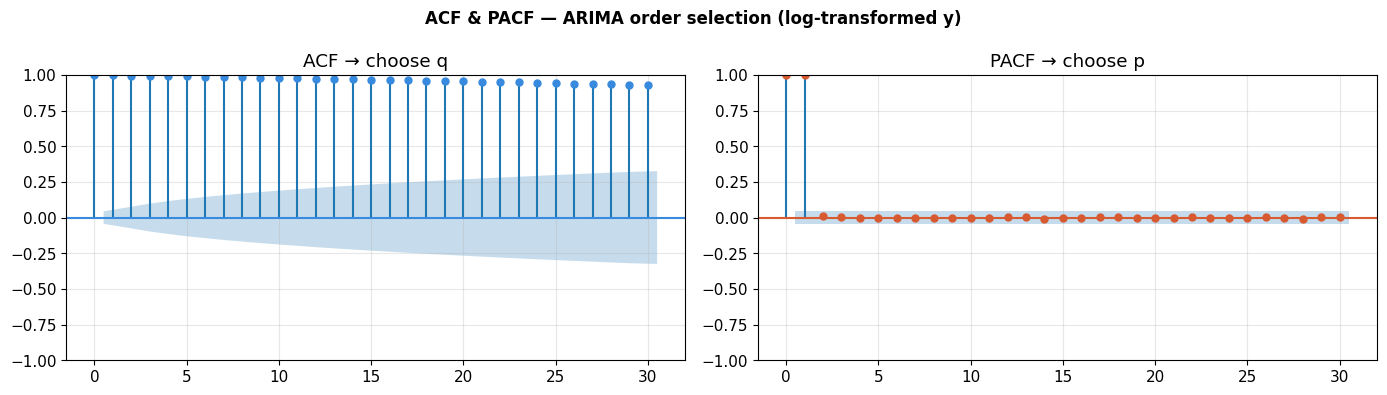

Saved: C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\plots\01_arima_acf_pacf.png


In [9]:
result = adfuller(y_train_series[:5000])
print(f"ADF p-value: {result[1]:.4f} \u2192 {'Stationary' if result[1]<0.05 else 'Non-stationary (use d=1)'}")

max_lags = min(30, len(y_train_series[:2000]) // 2 - 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('ACF & PACF — ARIMA order selection (log-transformed y)', fontsize=12, fontweight='bold')
plot_acf(y_train_series[:2000],  lags=max_lags, ax=axes[0], color='#378ADD')
axes[0].set_title('ACF \u2192 choose q')
plot_pacf(y_train_series[:2000], lags=max_lags, ax=axes[1], color='#D85A30', method='ywm')
axes[1].set_title('PACF \u2192 choose p')
plt.tight_layout()
out = os.path.join(PLOTS_DIR, '01_arima_acf_pacf.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out}")


## 5. Train ARIMA & Evaluate

In [10]:
ARIMA_TRAIN_N = min(10000, len(y_train_series))
ARIMA_VAL_N   = min(2000,  len(y_val_series))
ORDER = (5, 1, 0)

print(f"Training ARIMA{ORDER} on {ARIMA_TRAIN_N:,} log-space samples...")
model_fit = ARIMA(y_train_series[:ARIMA_TRAIN_N], order=ORDER).fit()

print(f"Forecasting {ARIMA_VAL_N:,} steps...")
pred_log    = np.clip(model_fit.forecast(steps=ARIMA_VAL_N), 0, None)
true_log    = y_val_series[:ARIMA_VAL_N]
pred_actual = np.expm1(pred_log)   # inverse log1p
true_actual = np.expm1(true_log)

r2   = r2_score(true_actual, pred_actual)
mae  = mean_absolute_error(true_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(true_actual, pred_actual))
mape = np.mean(np.abs((true_actual - pred_actual) / (true_actual + 1e-8))) * 100

print()
print('=' * 40)
print('MODEL EVALUATION REPORT')
print('=' * 40)
print(f'MAE  (Mean Absolute Error):     {mae:.4f} cores')
print(f'RMSE (Root Mean Squared Error): {rmse:.4f} cores')
print(f'R\u00b2   (Explained Variance):      {r2:.4f}')
print(f'MAPE (Mean Absolute % Error):   {mape:.2f}%')
print(f'Evaluated on:                   {len(true_actual):,} samples')
print('=' * 40)
save_result('ARIMA', r2, mae, rmse, mape)


Training ARIMA(5, 1, 0) on 10,000 log-space samples...
Forecasting 2,000 steps...

MODEL EVALUATION REPORT
MAE  (Mean Absolute Error):     35.9923 cores
RMSE (Root Mean Squared Error): 91.7022 cores
R²   (Explained Variance):      -0.1587
MAPE (Mean Absolute % Error):   567.56%
Evaluated on:                   2,000 samples
  Saved → results/all_models_results.csv


## 6. Plots

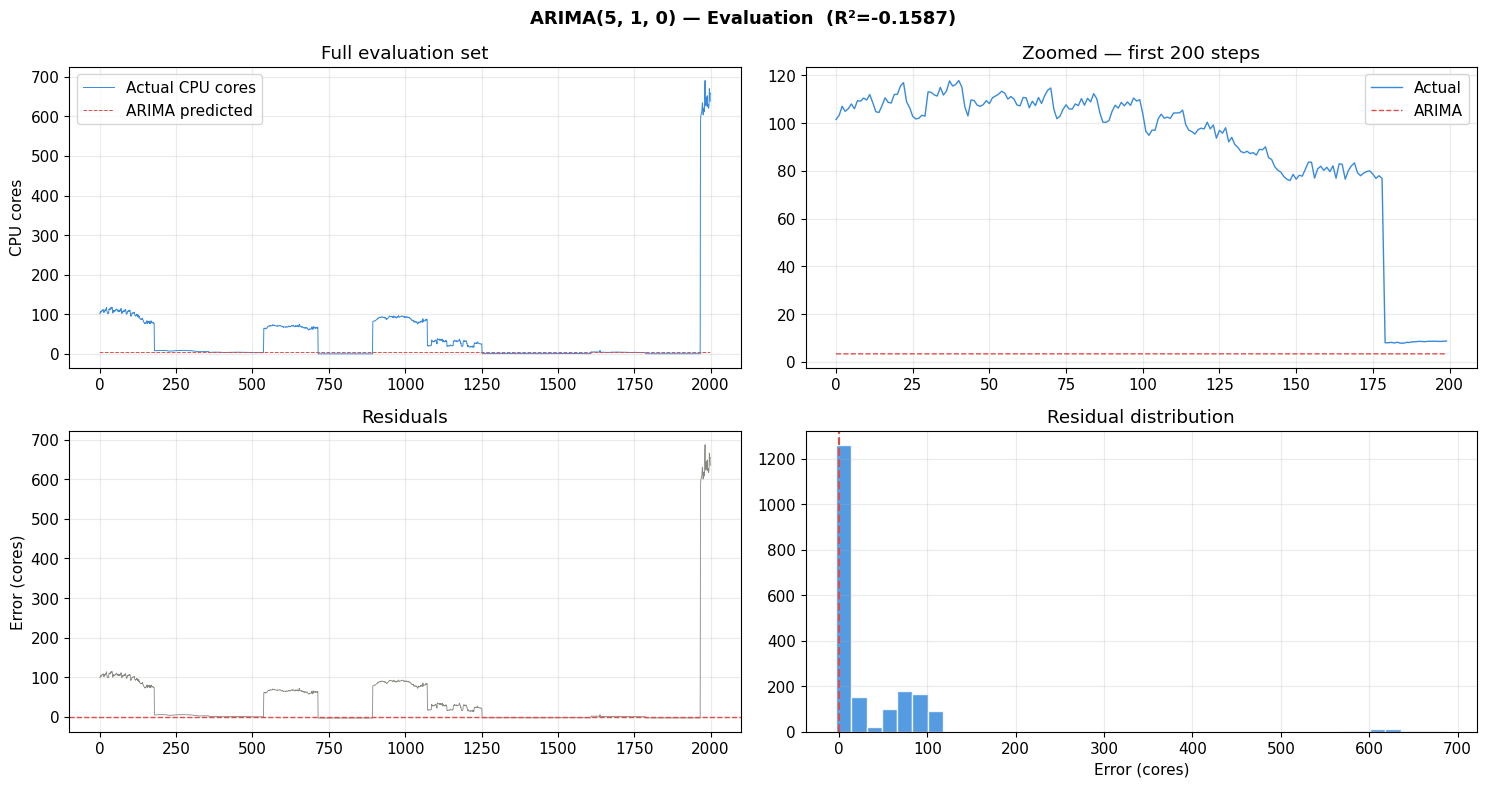

Saved: C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\plots\01_arima_results.png
Final — R²=-0.1587 | MAE=35.9923 | RMSE=91.7022 | MAPE=567.56%


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f'ARIMA{ORDER} — Evaluation  (R\u00b2={r2:.4f})', fontsize=13, fontweight='bold')

axes[0][0].plot(true_actual, color='#378ADD', linewidth=0.7, label='Actual CPU cores')
axes[0][0].plot(pred_actual, color='#E24B4A', linewidth=0.7, linestyle='--', label='ARIMA predicted')
axes[0][0].set_title('Full evaluation set'); axes[0][0].set_ylabel('CPU cores'); axes[0][0].legend()

n = min(200, len(pred_actual))
axes[0][1].plot(true_actual[:n], color='#378ADD', linewidth=1.0, label='Actual')
axes[0][1].plot(pred_actual[:n], color='#E24B4A', linewidth=1.0, linestyle='--', label='ARIMA')
axes[0][1].set_title(f'Zoomed — first {n} steps'); axes[0][1].legend()

res = true_actual - pred_actual
axes[1][0].plot(res, color='#888780', linewidth=0.6)
axes[1][0].axhline(0, color='#E24B4A', linestyle='--', linewidth=1)
axes[1][0].set_title('Residuals'); axes[1][0].set_ylabel('Error (cores)')

axes[1][1].hist(res, bins=40, color='#378ADD', edgecolor='white', alpha=0.85)
axes[1][1].axvline(0, color='#E24B4A', linestyle='--')
axes[1][1].set_title('Residual distribution'); axes[1][1].set_xlabel('Error (cores)')

for ax in axes.flatten(): ax.grid(True, alpha=0.25)
plt.tight_layout()
out = os.path.join(PLOTS_DIR, '01_arima_results.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out}")
print(f"Final \u2014 R\u00b2={r2:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f} | MAPE={mape:.2f}%")
